In [1]:
from importlib import reload
import torch
import numpy as np
import time
import os
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:4" if torch.cuda.is_available() else "cpu")
print(device)
cupy_device = device.index if device.type == "cuda" else 0
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.append(r"../main_code/2d")
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_2d,net_2d,source_eval,error_general_2d,main
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


def f_circle(x,x_left,x_right,y_below,y_upper,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1)
    # Apply the piecewise function
    f_y_values = np.where(r_y < r , 1.0, 0.0)
    return f_y_values

def f_rec(x,x_left,x_right,y_below,y_upper,center,r):
    cond= (x[:,0]>=x_left) & (x[:,0]<=x_right) & (x[:,1]>=y_below) & (x[:,1]<=y_upper)
    return cond*1

def ana_S(x,x_left,x_right,y_below,y_upper,center,r): # x is the data array; a and b are center coordinates
    return f_circle(x,x_left,x_right,y_below,y_upper,center,r)-f_rec(x,x_left,x_right,y_below,y_upper,center,r)


cuda:4


### noise=0.5%

In [2]:
import copy
Nx,Ny=1,1
Ix,Iy=8,8  # Number of grid cells in the x direction
nx,ny=3,3  # Gauss points per cell in the x direction
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max=-0.5,1.5,-0.5,1.5 # On boundary Gamma

num_batches_gauss=1
b_n=10
points_b=mea_2d.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) # Collect data on boundary Gamma
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.2
center_true=np.array([0.71,0.5])
number_gene=50
eps=0.005
batch_number_rec_mea,mea=2,1
cupy_device = device.index if device.type == "cuda" else 0
S_int_true1, F_mea_b1, F_mea_db_x11, F_mea_db_x21 = generate_data.boundary_data_rec(kk, number_gene,points_b, f_rec, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
S_int_true2, F_mea_b2, F_mea_db_x12, F_mea_db_x22 = generate_data.boundary_data_circle(kk, number_gene,points_b, f_circle, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
F_mea_b_05 = -F_mea_b1 + F_mea_b2
F_mea_db_x1_05 = -F_mea_db_x11 + F_mea_db_x12
F_mea_db_x2_05 = -F_mea_db_x21 + F_mea_db_x22
F_05=inverse_solver.F(F_mea_b_05,F_mea_db_x1_05,F_mea_db_x2_05)

cells= mesh.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) # Create the initial grid
initial_cells=copy.deepcopy(cells) # Make a copy
R_m=20


In [3]:
M=1600
af="Tanh"   # Initial activation setting
R_m=20
cupy_device = device.index if device.type == "cuda" else 0
models = net_2d.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)


In [4]:
from importlib import reload
reload(main)
reload(adaptive_int)


<module 'adaptive_int' from '/data1/hxw-b25/MA-RFM/Ex4.5/../main_code/2d/adaptive_int.py'>

/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


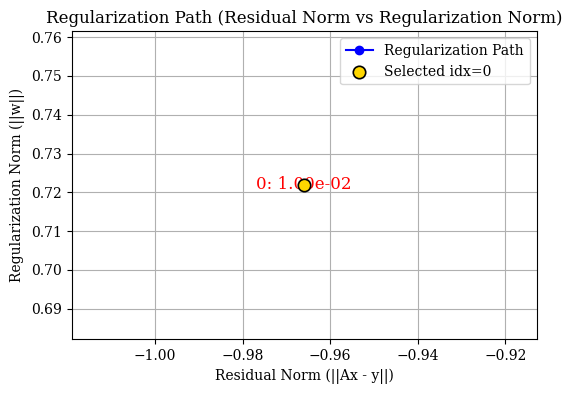

Training error at iteration 0 :
Generalization error at iteration 0 :


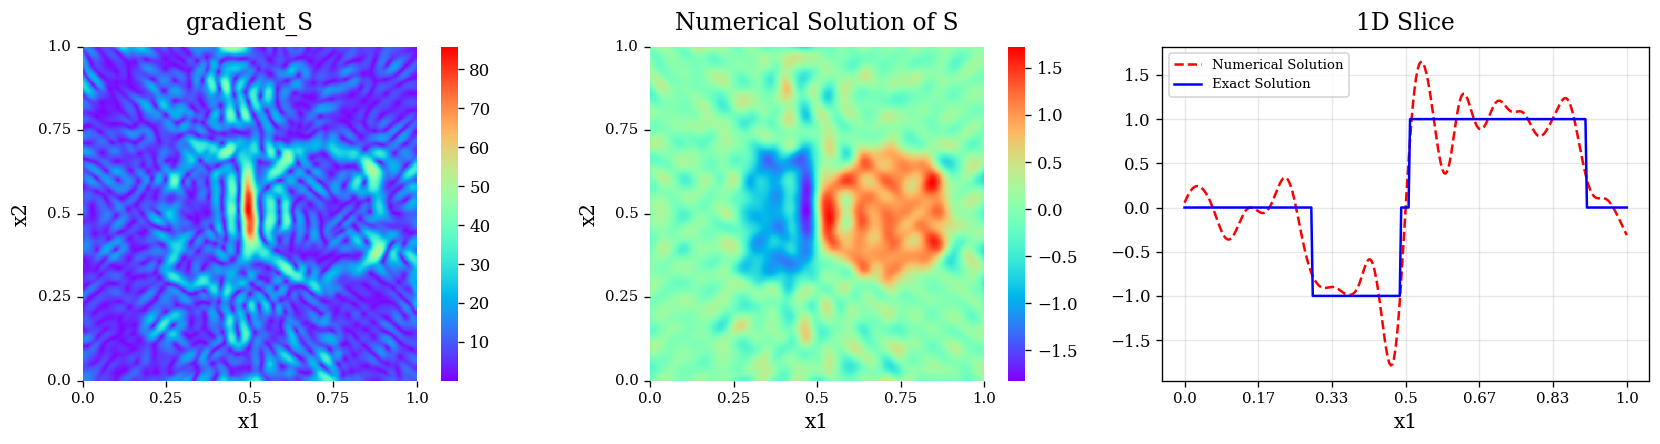

S_l_inf= 2.721634086724029 S_L_2= 0.21355797905889326 S_l_2= 0.4728202477606797
Adaptive mesh refinement at iteration 0 ...
Generating visualizations...
1. Plotting mesh comparison...


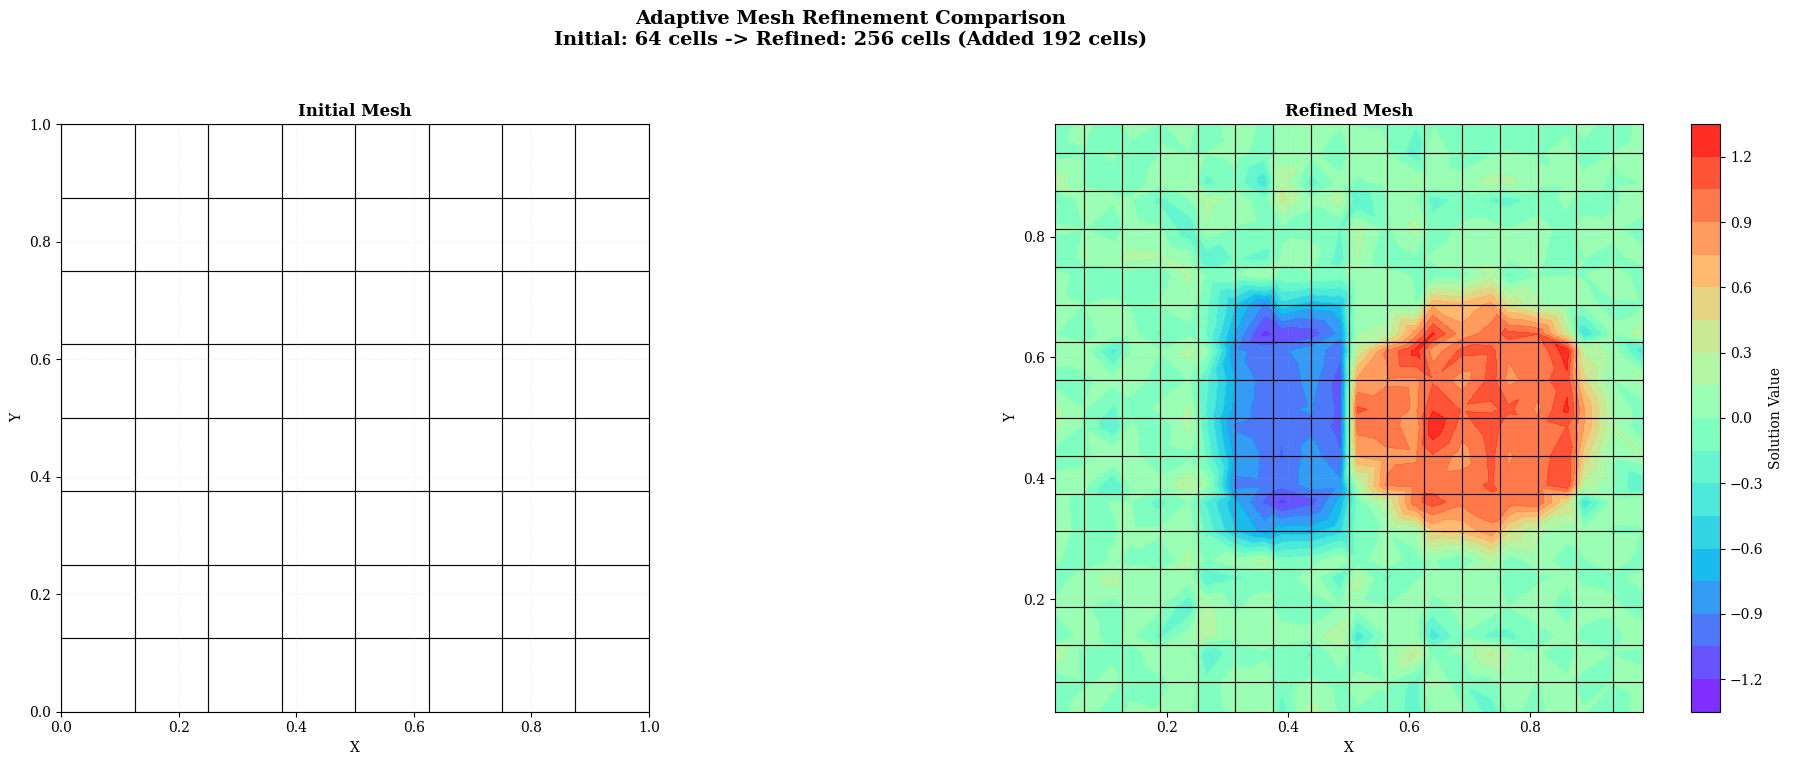

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


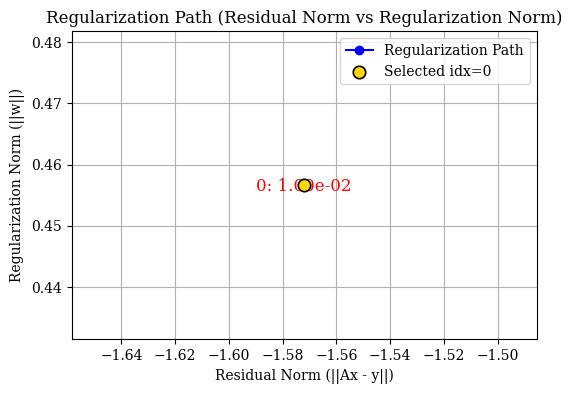

Training error at iteration 1 :
Generalization error at iteration 1 :


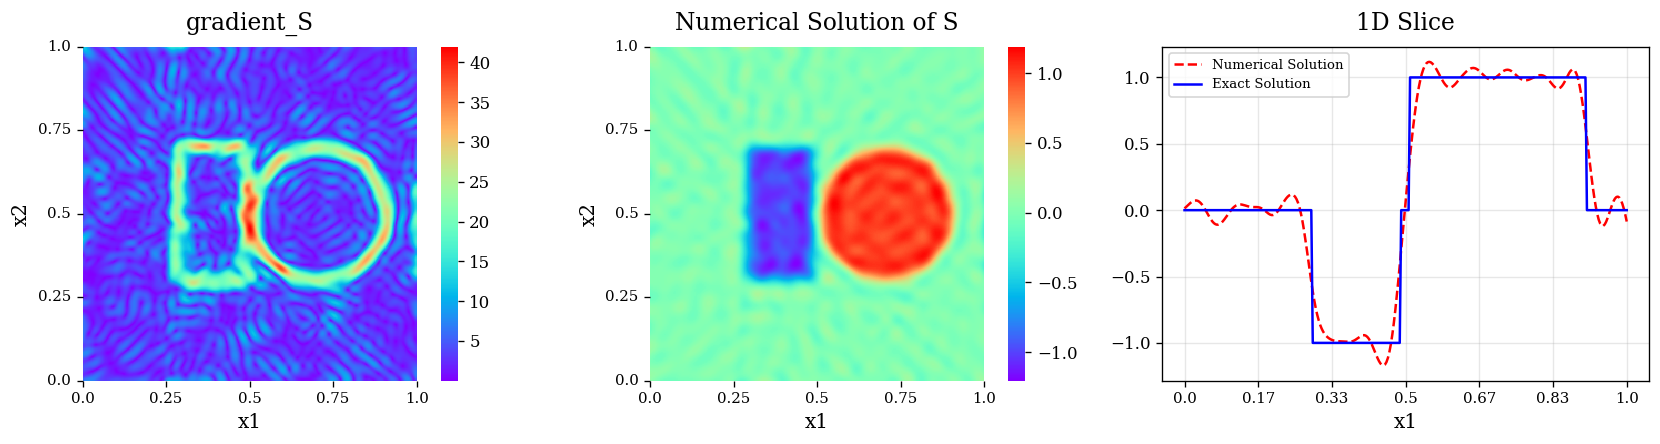

S_l_inf= 1.6531925525463473 S_L_2= 0.10565263856244177 S_l_2= 0.23391636763844428
Adaptive mesh refinement at iteration 1 ...
Generating visualizations...
1. Plotting mesh comparison...


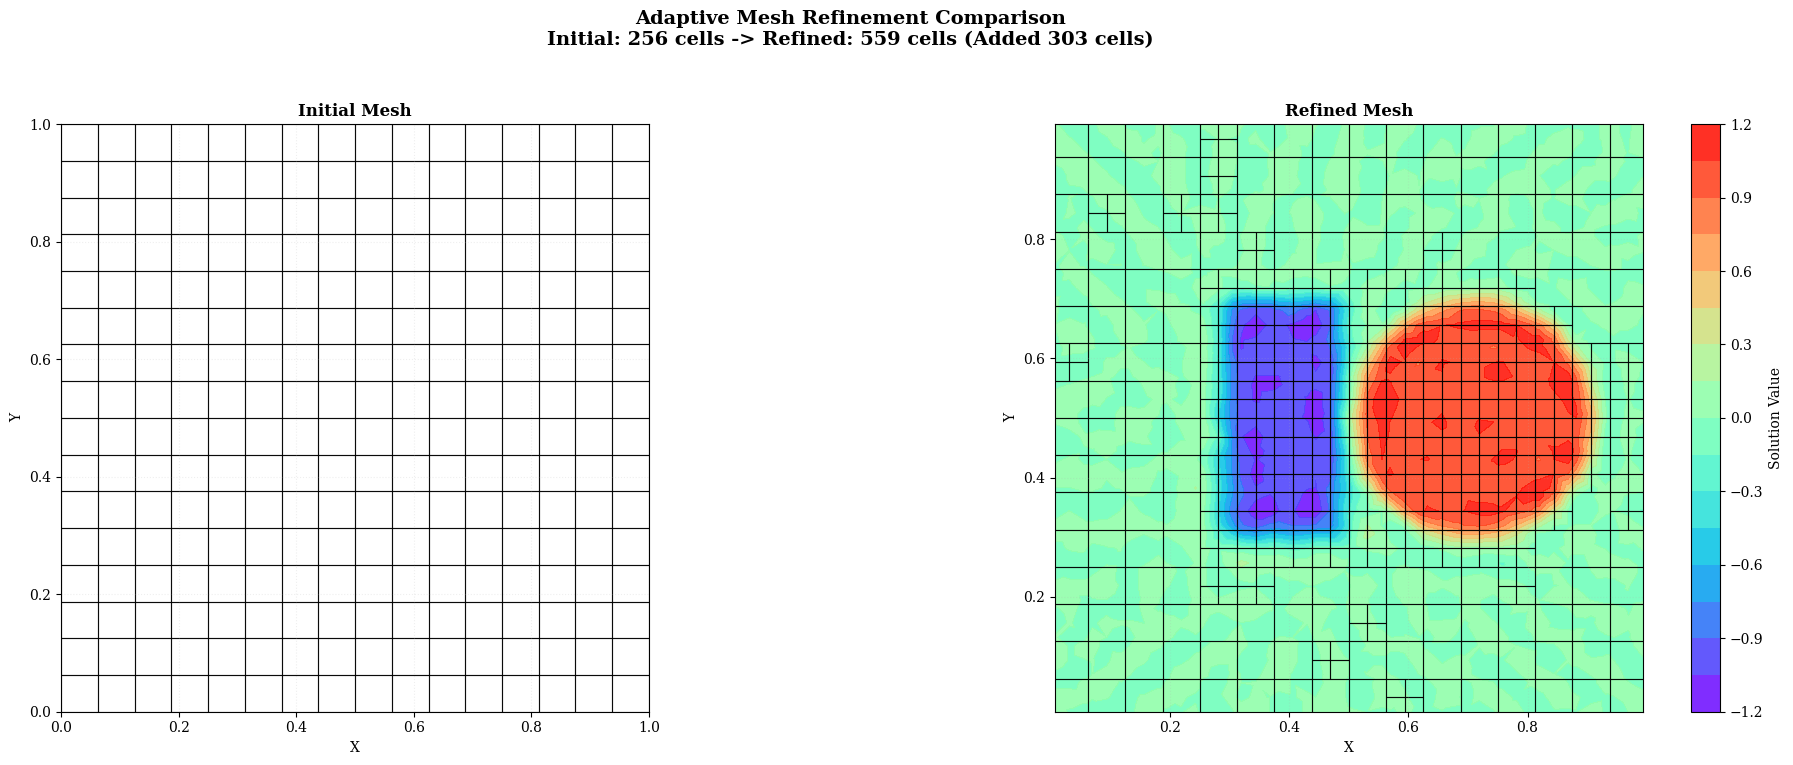

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


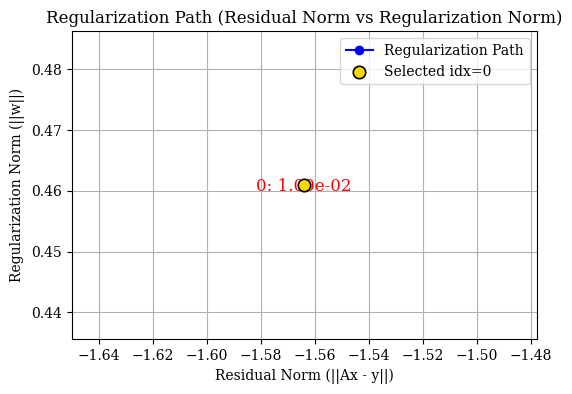

Training error at iteration 2 :
Generalization error at iteration 2 :


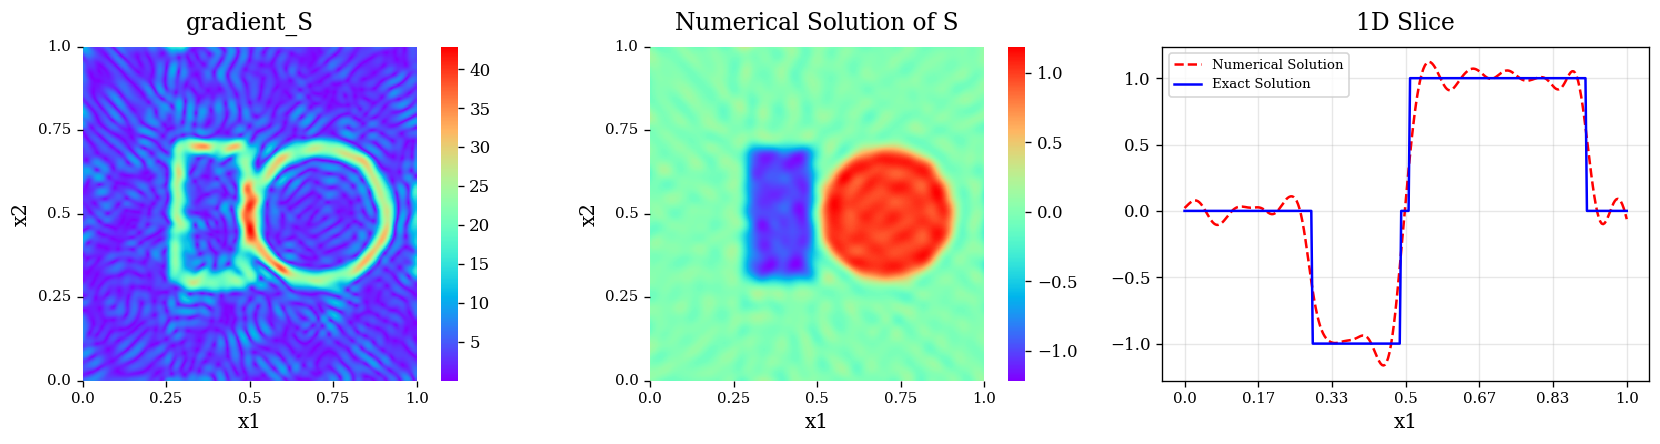

S_l_inf= 1.665760258423091 S_L_2= 0.10586094991957712 S_l_2= 0.23437757179445914
Adaptive mesh refinement at iteration 2 ...
Generating visualizations...
1. Plotting mesh comparison...


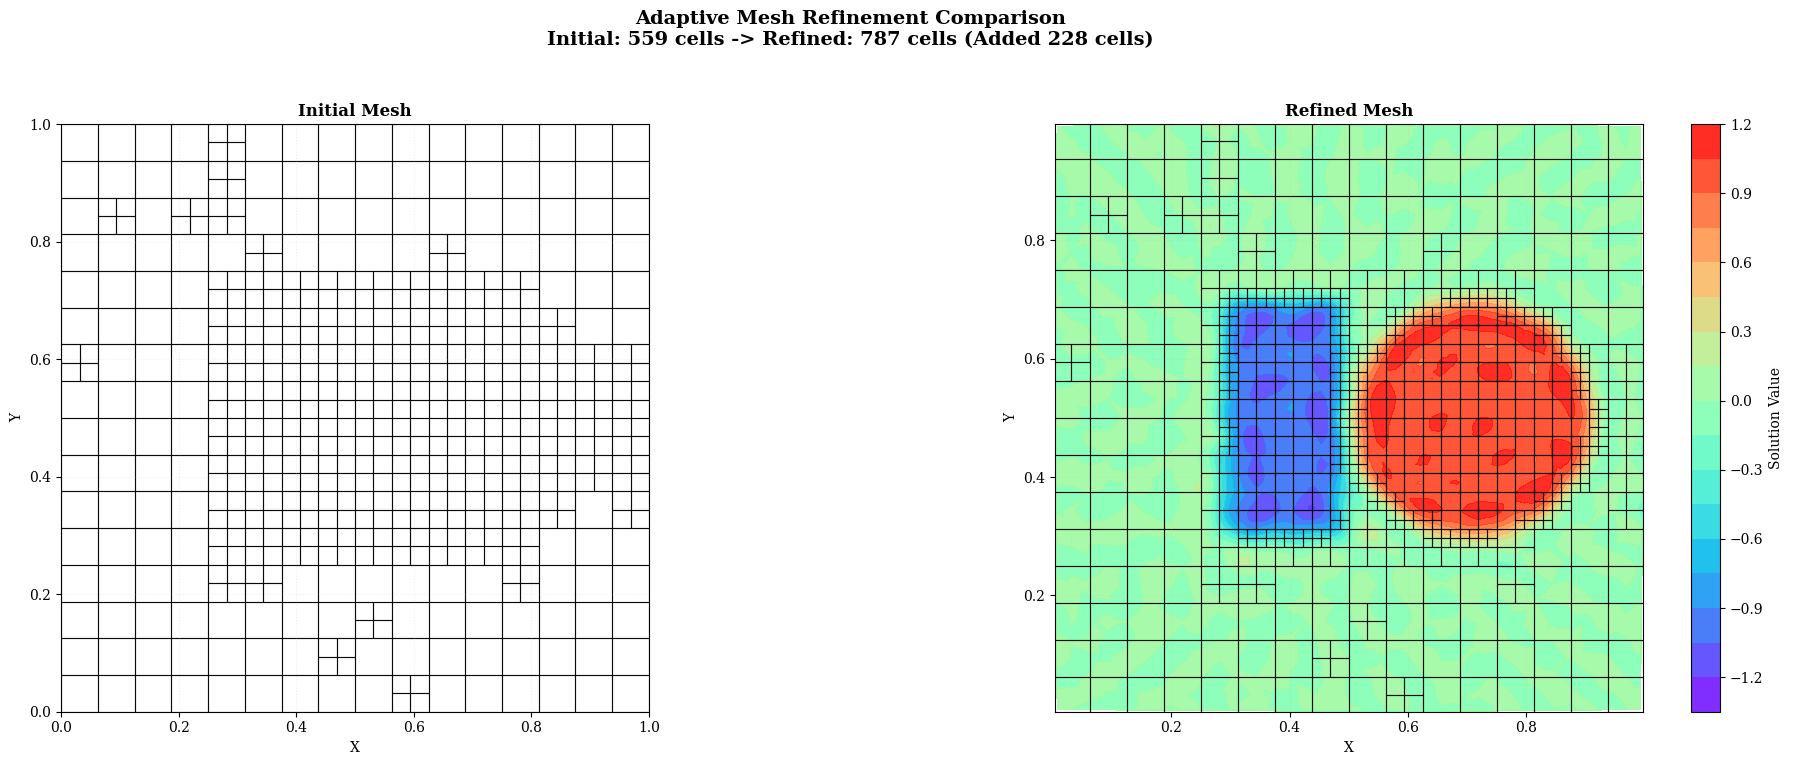

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


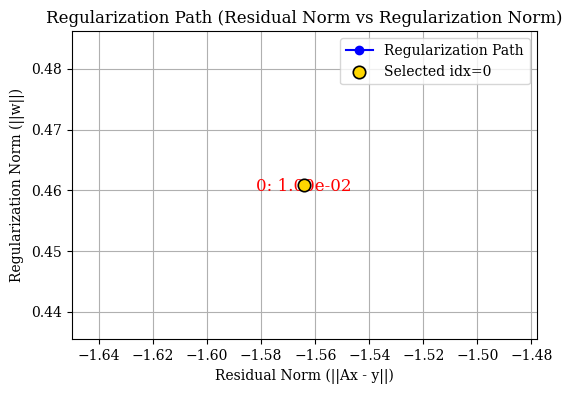

Training error at iteration 3 :
Generalization error at iteration 3 :


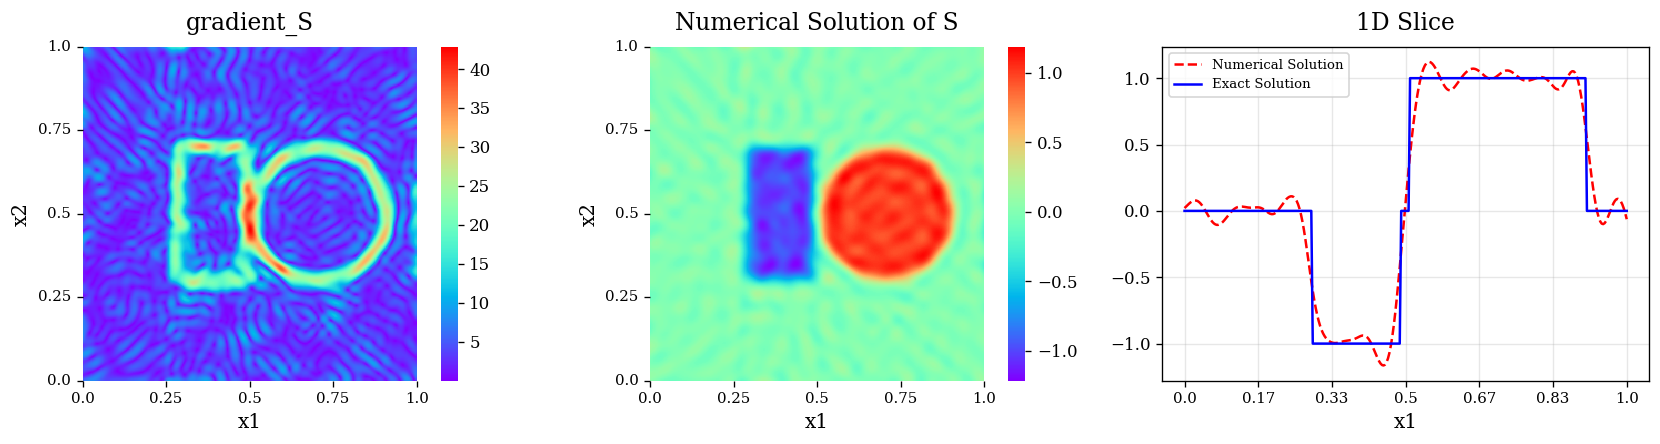

S_l_inf= 1.6656990975836734 S_L_2= 0.1058547857867553 S_l_2= 0.2343639243212021
Stop at iteration 3


In [5]:
iter_int= 5
Ix,Iy=4,4  # Number of grid cells in the x direction
delta=10**(-3)
nx=3
lamb_regu=np.logspace(-2,-1,1)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="Tanh"
refine_threshold_S=1/100
refine_threshold_grad=1/300
Shape=[]
cells_store,refinement_stats_store,w_,point_number,S_num_store,g_store,g_S,S_l2=main.ada_int(iter_int,delta,cells,nx,models,M,af,Shape,kk,F_05,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,points_b,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,current_maxiter,max_level)


DBSCAN eps = 0.016667 (5.000000 * h, h = 0.003333)
Number of detected clusters: 2
  CV of S_num: 0.247
Cluster 0: AR=1.89
  Res_Rect=0.026101 vs Res_Ellip=0.132437
  center=(0.3904, 0.4977)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.248
Cluster 1: AR=1.00
  Res_Rect=0.087633 vs Res_Ellip=0.015209
  center=(0.7107, 0.4994)
  -> Decision: Ellipsoid (Sigmoid)


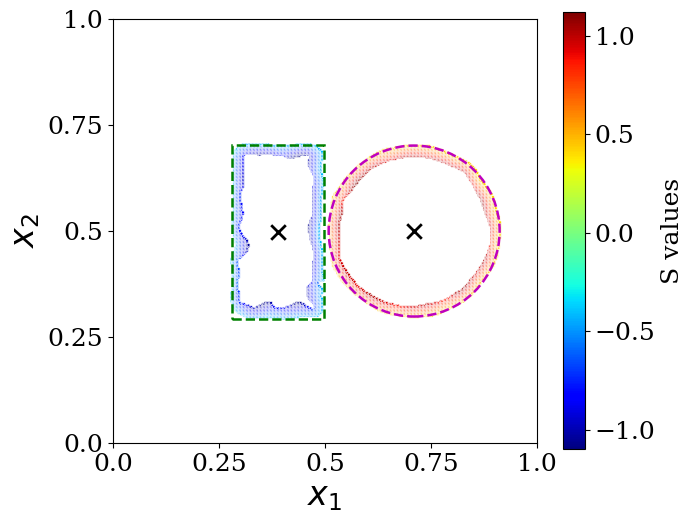

LaTeX table rows:
{\emph{Ex}} & Cluster $k$ & $\boldsymbol{c}_k$ & $r_k$ or $\boldsymbol{L}_k$ & $\mathcal{E}_{\mathrm{rect}}^{(k)}$ & $\mathcal{E}_{\mathrm{ellip}}^{(k)}$ & $\mathrm{AR}_k$ & $\mathrm{CV}_k$ & $\mathcal{T}_k$ & $\sigma_k$ \\
\multirow{2}{*}{Ex 4.5} & 1 & (3.90e-01, 4.98e-01) & $\boldsymbol{L}$=(1.08e-01, 2.05e-01) & 0.0261 & 0.1324 & 1.89 & 0.247 & \textbf{Rectangle} & Sigmoid \\
 & 2 & (7.11e-01, 4.99e-01) & $\boldsymbol{L}$=(2.02e-01, 2.02e-01) & 0.0876 & 0.0152 & 1.00 & 0.248 & \textbf{Ellipsoid} & Sigmoid \\


['{\\emph{Ex}} & Cluster $k$ & $\\boldsymbol{c}_k$ & $r_k$ or $\\boldsymbol{L}_k$ & $\\mathcal{E}_{\\mathrm{rect}}^{(k)}$ & $\\mathcal{E}_{\\mathrm{ellip}}^{(k)}$ & $\\mathrm{AR}_k$ & $\\mathrm{CV}_k$ & $\\mathcal{T}_k$ & $\\sigma_k$ \\\\',
 '\\multirow{2}{*}{Ex 4.5} & 1 & (3.90e-01, 4.98e-01) & $\\boldsymbol{L}$=(1.08e-01, 2.05e-01) & 0.0261 & 0.1324 & 1.89 & 0.247 & \\textbf{Rectangle} & Sigmoid \\\\',
 ' & 2 & (7.11e-01, 4.99e-01) & $\\boldsymbol{L}$=(2.02e-01, 2.02e-01) & 0.0876 & 0.0152 & 1.00 & 0.248 & \\textbf{Ellipsoid} & Sigmoid \\\\']

In [6]:
from importlib import reload
import bound_detect
reload(bound_detect)
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster=5.0
mini_samples=20
para_abs=3
para_grad=3
results=bound_detect.detect_shape(g_S,X.T,Y.T,tau_x_min,tau_x_max,tau_y_min,tau_y_max,para_abs,para_grad,eps_cluster,mini_samples,S_num_store[-1],output_directory="./Noise/noise=0.5%", output_filename="plot.png", eps_mode="grid_scaled")
print("LaTeX table rows:")
bound_detect.print_latex_result_rows(results, example_name="Ex 4.5", include_header=True)


In [7]:
results

[{'cluster_id': 0,
  'shape': 'Rectangle',
  'params': {'center': array([0.39042712, 0.49774832]),
   'W': np.float64(0.21666666666666667),
   'H': np.float64(0.41000000000000003)},
  'profile': 'Sigmoid',
  'boundary_points': array([[0.3996    , 0.29032333],
         [0.39899   , 0.29093333],
         [0.39838   , 0.29093333],
         ...,
         [0.40143   , 0.29032333],
         [0.40082   , 0.29032333],
         [0.40021   , 0.29032333]]),
  'diagnostics': {'Lx': 0.21666666666666667,
   'Ly': 0.41000000000000003,
   'aspect_ratio': 1.8923076923076925,
   'res_rect': 0.026100673052186732,
   'res_ellip': 0.1324368689314778,
   'residual_threshold': 0.05,
   'tori_ratio': 0.3284524849089558,
   'r_mean': 0.160629455625246,
   'min_dist_to_center': 0.07291423929876187,
   'max_dist_to_center': 0.2219932643194131,
   'dist_05': 0.08974683069328228,
   'dist_95': 0.21072088694189844},
  'aspect_ratio': 1.8923076923076925,
  'res_rect': 0.026100673052186732,
  'res_ellip': 0.132436868

In [8]:
rect_entry = next((item for item in results if item.get("shape") == "Rectangle"), None)
ellip_entry = next((item for item in results if item.get("shape") == "Ellipsoid"), None)
if rect_entry is None or ellip_entry is None:
    raise ValueError("Expected one Rectangle and one Ellipsoid detection.")

center1 = np.asarray(rect_entry["params"]["center"])
width = float(rect_entry["params"].get("W", 2 * rect_entry["params"].get("a", np.nan)))
height = float(rect_entry["params"].get("H", 2 * rect_entry["params"].get("b", np.nan)))
center2 = np.asarray(ellip_entry["params"]["center"])
a_ellip = float(ellip_entry["params"].get("a", ellip_entry["params"].get("radius")))
b_ellip = float(ellip_entry["params"].get("b", ellip_entry["params"].get("radius")))
r_equiv = float(ellip_entry["params"].get("radius", max(a_ellip, b_ellip)))


In [9]:
import net_2d

theta_min, theta_max = -1e-12, 1e-12
K_old_min = 1000
K_old_max = 20000
# Use the paper's 2D nondimensional K mapping:
#   K_ellip = (a*b) * K_old, with semi-axes a and b.
#   K_rec = sqrt((width/2)*(height/2)) * K_old = 0.5*sqrt(width*height) * K_old.
ellip_char = a_ellip * b_ellip
K_ellip_min = ellip_char * K_old_min
K_ellip_max = ellip_char * K_old_max
rect_char = 0.5 * np.sqrt(width * height)
K_rec_min = rect_char * K_old_min
K_rec_max = rect_char * K_old_max

def _ordered_bounds(v1, v2):
    return (min(float(v1), float(v2)), max(float(v1), float(v2)))

min_rec1, max_rec1 = _ordered_bounds(-center1[0] * (1 + 0.05), -center1[0] * (1 - 0.05))
min_rec2, max_rec2 = _ordered_bounds(-center1[1] * (1 + 0.05), -center1[1] * (1 - 0.05))
min_ellip1, max_ellip1 = _ordered_bounds(center2[0] * (1 - 0.05), center2[0] * (1 + 0.05))
min_ellip2, max_ellip2 = _ordered_bounds(center2[1] * (1 - 0.05), center2[1] * (1 + 0.05))
axis_a_min, axis_a_max = _ordered_bounds(a_ellip * (1 - 0.1), a_ellip * (1 + 0.05))
axis_b_min, axis_b_max = _ordered_bounds(b_ellip * (1 - 0.1), b_ellip * (1 + 0.05))
width_min, width_max = _ordered_bounds(width * (1 - 0.1), width * (1 + 0.05))
height_min, height_max = _ordered_bounds(height * (1 - 0.1), height * (1 + 0.05))
models0 = models
models1 = net_2d.pre_define(
    Nx, Ny, 2400, R_m, "sigmoid", tau_x_min, tau_x_max, tau_y_min, tau_y_max,
    theta_min, theta_max, min_ellip1, max_ellip1, min_ellip2, max_ellip2,
    axis_a_min, axis_a_max, axis_b_min, axis_b_max,
    [], [], [], [], K_ellip_min, K_ellip_max, "ellipsoid", device,
)
models2 = net_2d.pre_define(
    Nx, Ny, 2400, R_m, "sigmoid", tau_x_min, tau_x_max, tau_y_min, tau_y_max,
    [], [], min_rec1, max_rec1, min_rec2, max_rec2,
    width_min, width_max, height_min, height_max,
    [], [], [], [], K_rec_min, K_rec_max, "rec", device,
)
af = "mix"
sum_mat, all_g_p1, all_g_n, cells_copy1 = matrix_assemble.mat_assemble2(
    cells_store[-1], models0, models1, models2, "mix", "ellipsoid", "rec", kk, 0, points_b, device, cupy_device
)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


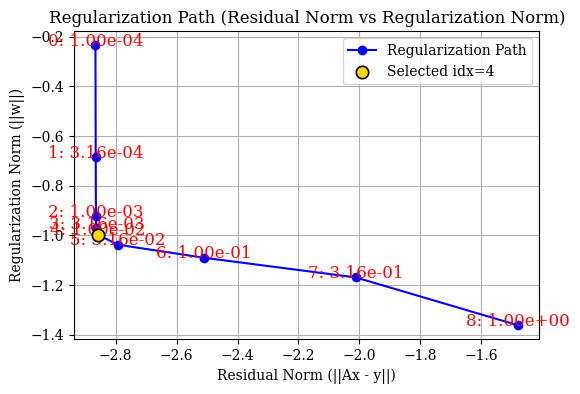

In [10]:
lamb_regu=np.logspace(-4,0,9,endpoint=True)
res,reg_norm,w_store=inverse_solver.L_curve(sum_mat,F_05,[],[],[],lamb_regu,"linear",device,cupy_device) # Solve first for q

L-curve corner index: 4
Curvature-centered lambda window:
  idx=3, lambda=3.162278e-03, curvature=6.976980e+00
  idx=4, lambda=1.000000e-02, curvature=9.841015e+00 <== center
  idx=5, lambda=3.162278e-02, curvature=3.976816e-01
candidate idx: [3 4 5]
candidate lambda: [0.00316228 0.01       0.03162278]


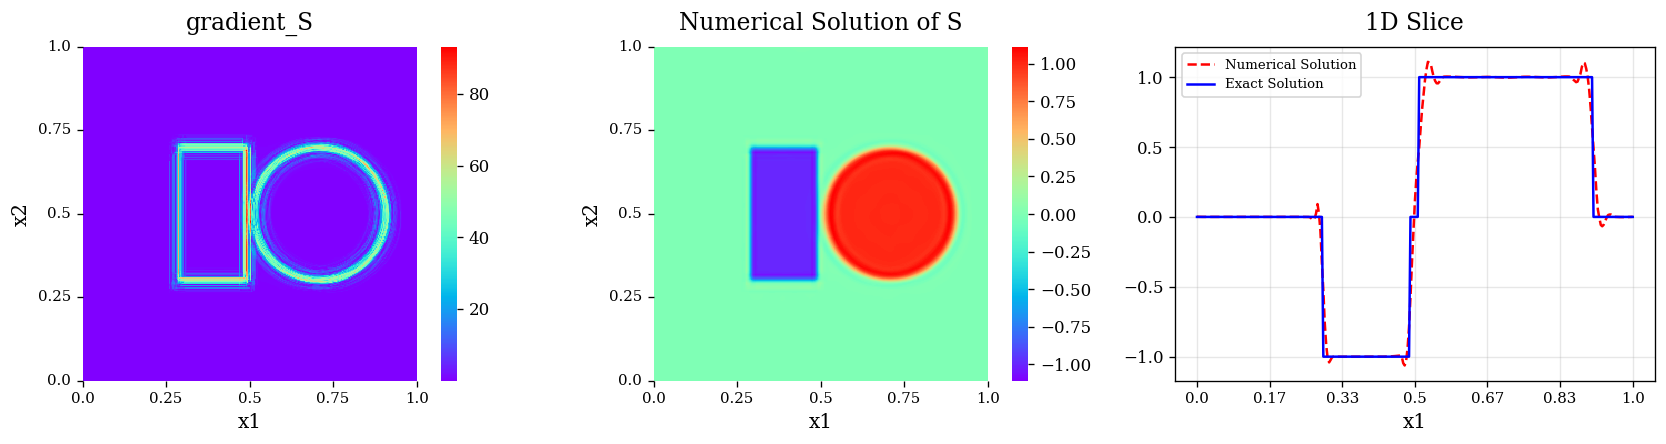

S_l_inf= 1.6079269994904524 S_L_2= 0.06530910071719533 S_l_2= 0.14459523038292002
candidate idx=3, lamb=1e-05, S_l_inf=1.6079269994904524, S_l_2=0.14459523038292002


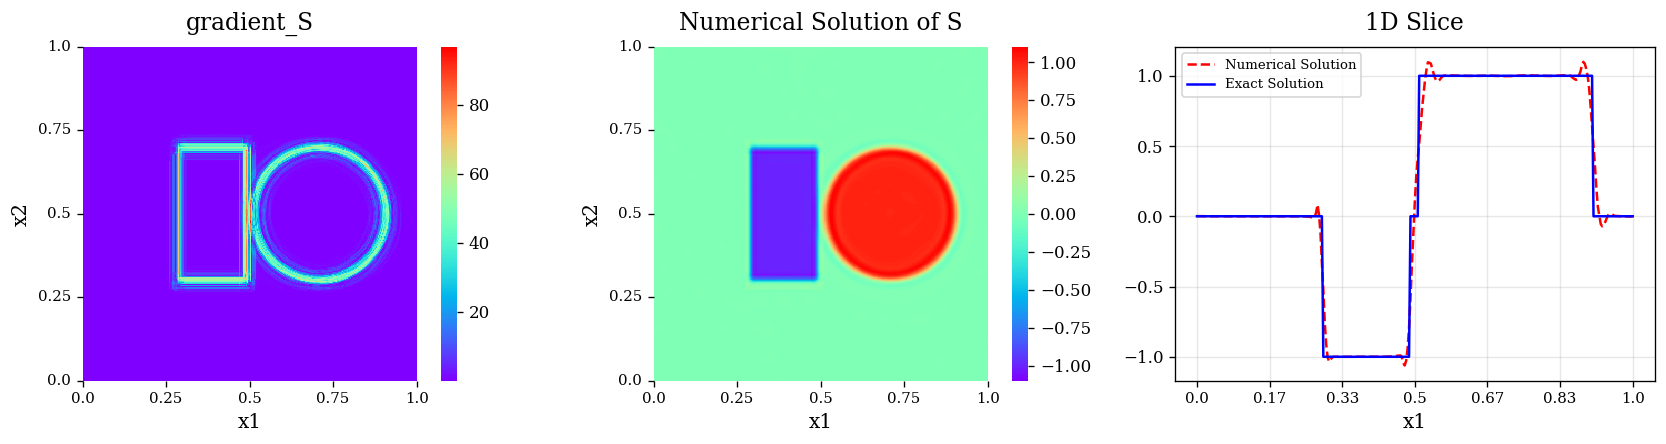

S_l_inf= 1.6068344640517362 S_L_2= 0.06605309195486991 S_l_2= 0.14624243702384848
candidate idx=4, lamb=0.0001, S_l_inf=1.6068344640517362, S_l_2=0.14624243702384848


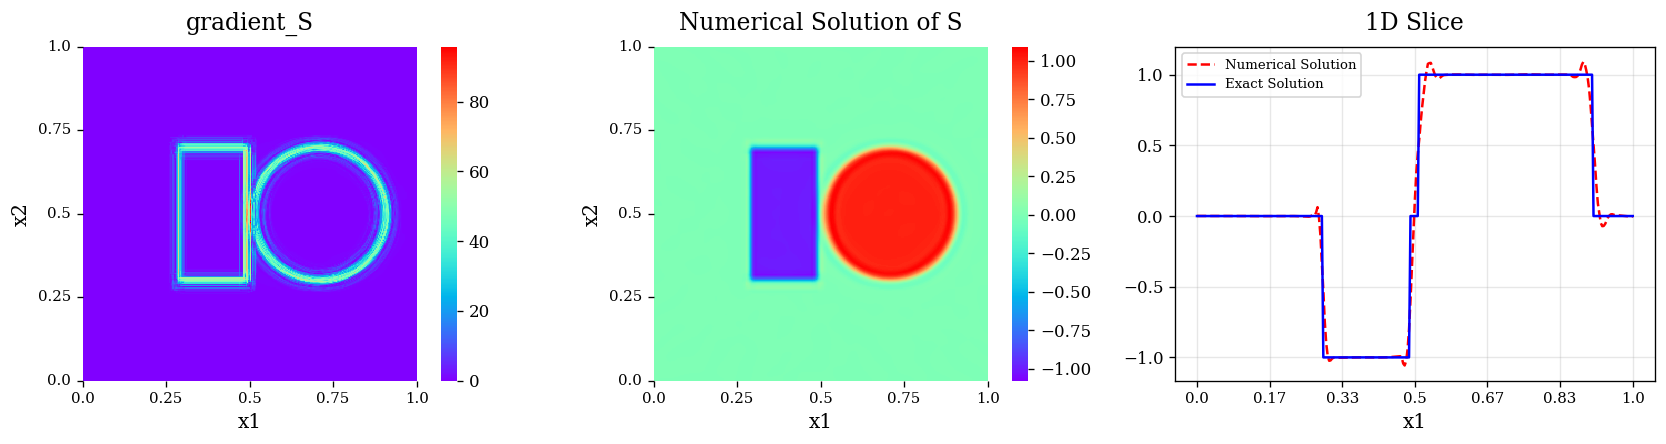

S_l_inf= 1.6220245497441759 S_L_2= 0.0678936087697774 S_l_2= 0.15031736609120153
candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.6220245497441759, S_l_2=0.15031736609120153
picked idx: 3
lamb: 1e-05


In [11]:
reload(inverse_solver)
window_idx, window_lambda, window_w, curvature = inverse_solver.lambda_window_by_curvature(
    lamb_regu, res, reg_norm, radius=1, w_store=w_store
)
print('candidate idx:', window_idx)
print('candidate lambda:', window_lambda)
window_results = []
for local_i, cand_idx in enumerate(window_idx):
    cand_lamb = window_lambda[local_i]**2
    cand_w = window_w[:, local_i]
    result_tuple = error_general_2d.test(models0,models1,models2,[],Qx,Qy,cand_w,"mix","ellipsoid","rec",True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,1,device)
    window_results.append({
        'idx': int(cand_idx),
        'lambda': cand_lamb,
        'w': cand_w,
        'result': result_tuple,
    })
    print(
        f"candidate idx={int(cand_idx)}, lamb={cand_lamb}, "
        f"S_l_inf={result_tuple[2]}, S_l_2={result_tuple[3]}"
    )
pick = 0
picked = window_results[pick]
idx = picked['idx']
lamb = picked['lambda']
picked_w = picked['w']
S_test_num,S_test_true,S_l_inf1,S_l_21,g_SS=picked['result']
print('picked idx:', idx)
print('lamb:', lamb)


In [12]:
import pickle

with open("./Noise/noise=0.5%/cells_store_last.pkl", "wb") as f:
    pickle.dump(cells_store[-1], f)

In [13]:
np.save(f"./Noise/noise=0.5%/S_num_1600+2400*2_{lamb}",S_test_num)
np.save("./Noise/noise=0.5%/all_mat",sum_mat)
np.save("./Noise/noise=0.5%/w_store",w_store)
np.save("./Noise/noise=0.5%/F_mea_b",F_mea_b_05)
np.save("./Noise/noise=0.5%/F_mea_db_x1",F_mea_db_x1_05)
np.save("./Noise/noise=0.5%/F_mea_db_x2",F_mea_db_x2_05)

In [14]:
# Save the models1 model
torch.save(models0,f"./Noise/noise=0.5%/models0_33_1600_{point_number[-1]}_{lamb}.pth")
torch.save(models1,f"./Noise/noise=0.5%/models1_33_2400_ellipsoid.pth")
torch.save(models2,f"./Noise/noise=0.5%/models2_33_2400_rec.pth")


In [15]:
np.save("./Noise/noise=0.5%/g_S1",g_SS)

In [16]:
parameters05 = {
    "I_grid":Ix,
    "gauss_n":nx,
    "number_gene":number_gene,
    "noise":eps,
    "k": kk,
    "M0": 1600,
    "M1": 2400,
    "M2": 2400,
    "Tanh_Rm":20,
    "Gauss_R_m": R_m,
    "refinement_stats_store":refinement_stats_store,
    "points_number_ada:":point_number,
    "theta_min": theta_min,
    "theta_max": theta_max,
    "min_rec1": min_rec1,
    "max_rec1": max_rec1,
    "min_rec2": min_rec2,
    "max_rec2": max_rec2,
    "width_min": width_min,
    "width_max": width_max,
    "height_min": height_min,
    "height_max": height_max,
    "min_ellip1": min_ellip1,
    "max_ellip1": max_ellip1,
    "min_ellip2": min_ellip2,
    "max_ellip2": max_ellip2,
    "axis_a_min": axis_a_min,
    "axis_a_max": axis_a_max,
    "axis_b_min": axis_b_min,
    "axis_b_max": axis_b_max,
    "K_old_min": K_old_min,
    "K_old_max": K_old_max,
    "ellip_char": ellip_char,
    "rect_char": rect_char,
    "K_ellip_min": K_ellip_min,
    "K_ellip_max": K_ellip_max,
    "K_rec_min": K_rec_min,
    "K_rec_max": K_rec_max,
}


In [17]:
import pickle # Import the pickle module
output_pickle_file = "./Noise/noise=0.5%/parameters.pkl"
with open(output_pickle_file, 'wb') as f: # 'wb' for write binary
    pickle.dump(parameters05, f)

In [18]:
n_integral=len(cells_store[-1])*9
print('n_integral:',n_integral)
print('center1[0]:',center1)
print('center2[1]:',center2)
print('width:',width)
print('height:',height)

print('a_ellip:', a_ellip)
print('b_ellip:', b_ellip)
print('r_equiv:', r_equiv)
print('S_l2[-1]:',S_l2[-1])
print('lamb_regu:',lamb)
print('S_l21:',S_l_21)


n_integral: 7083
center1[0]: [0.39042712 0.49774832]
center2[1]: [0.71074221 0.49939509]
width: 0.21666666666666667
height: 0.41000000000000003
a_ellip: 0.20166666666666672
b_ellip: 0.2016666666666667
r_equiv: 0.20254923901338423
S_l2[-1]: 0.2343639243212021
lamb_regu: 1e-05
S_l21: 0.14459523038292002
